In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from transformers import AutoModelForCausalLM
from tuned_lens import TunedLens

MODEL_NAME = "EleutherAI/pythia-160m-deduped"
DATA_DIR = Path("../token_evolution_data/excerpts")
N_LAYERS = 13  # layers 0-12: embedding + 12 transformer blocks

# Load model
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)
model.float().eval()
final_ln = model.gpt_neox.final_layer_norm

# Load TunedLens (for Part 3: translated hidden states)
tuned_lens = TunedLens.from_model_and_pretrained(model, map_location="cpu").float()
tuned_lens.eval()
torch.set_grad_enabled(False)

print("Model and TunedLens loaded.")

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 1176.41it/s, Materializing param=gpt_neox.layers.11.post_attention_layernorm.weight] 


Model and TunedLens loaded.


In [ ]:
excerpt_files = sorted(DATA_DIR.glob("excerpt_*.npz"))
print(f"Found {len(excerpt_files)} excerpts")

categories = ["never", "by_4", "by_0"]
cat_labels = {
    "never": "Never stabilize",
    "by_4": "Stable by layer 4",
    "by_0": "Stable by layer 0",
}

# Accumulators for average cosine similarity matrices
cos_sum_raw = {c: np.zeros((N_LAYERS, N_LAYERS)) for c in categories}
cos_sum_tl  = {c: np.zeros((N_LAYERS, N_LAYERS)) for c in categories}
token_count = {c: 0 for c in categories}


def accumulate_cos(h, acc):
    """Accumulate pairwise layer cosine similarities. h: (L, N, D), acc: (L, L)."""
    norms = np.linalg.norm(h, axis=2, keepdims=True) + 1e-10
    h_n = h / norms
    cos = np.einsum("ink,jnk->ijn", h_n, h_n)  # (L, L, N)
    acc += cos.sum(axis=2)


for fi, fpath in enumerate(excerpt_files):
    if fi % 200 == 0:
        print(f"  Processing {fi}/{len(excerpt_files)} ...")

    data = np.load(fpath, allow_pickle=True)
    hs = data["hidden_states"]          # (13, seq_len, 768)
    top_ids = data["tl_top_token_ids"]   # (13, seq_len)

    seq_len = hs.shape[1]
    end = seq_len - 1  # drop last token
    if end <= 0:
        continue

    # Writable float32 copy, dropping last token
    hs_work = np.array(hs[:, :end, :], dtype=np.float32)

    # ── Part 1: apply final layer norm to the last hidden state ──
    hs_work[12] = final_ln(torch.tensor(hs_work[12])).numpy()

    # ── Persistent top-1 layer (stabilization criterion) ──
    top_work = top_ids[:, :end]
    matches = top_work == top_work[-1:]
    cum = np.cumprod(matches[::-1], axis=0)[::-1]
    player = np.argmax(cum, axis=0)   # (end,)

    masks = {
        "never": player == 12,   # top-1 only matches at the final layer
        "by_4":  player <= 4,    # stabilizes at or before layer 4
        "by_0":  player == 0,    # top-1 never changes across depth
    }

    # TunedLens translated hidden states
    hs_tl_arr = np.empty_like(hs_work)
    for l in range(12):
        h = torch.tensor(hs_work[l])  # layers 0-11 are un-modified raw states
        h_t = tuned_lens.transform_hidden(h, l)
        h_ln = tuned_lens.unembed.final_norm(h_t)
        hs_tl_arr[l] = h_ln.numpy()
    hs_tl_arr[12] = hs_work[12]  # already final-LN'd from Part 1

    # Accumulate cosine similarities by category
    for cat, mask in masks.items():
        n = int(mask.sum())
        if n == 0:
            continue
        token_count[cat] += n
        accumulate_cos(hs_work[:, mask, :],    cos_sum_raw[cat])
        accumulate_cos(hs_tl_arr[:, mask, :],  cos_sum_tl[cat])

# Compute mean cosine similarity matrices
cos_mean_raw = {c: cos_sum_raw[c] / max(token_count[c], 1) for c in categories}
cos_mean_tl  = {c: cos_sum_tl[c]  / max(token_count[c], 1) for c in categories}

print("\nToken counts per category:")
for c in categories:
    print(f"  {cat_labels[c]}: {token_count[c]:,}")
print("Done.")

Found 1605 excerpts
  Processing 0/1605 ...
  Processing 200/1605 ...
  Processing 400/1605 ...
  Processing 600/1605 ...
  Processing 800/1605 ...
  Processing 1000/1605 ...
  Processing 1200/1605 ...
  Processing 1400/1605 ...
  Processing 1600/1605 ...

Token counts per category:
  Never stabilize: 105,078
  Stable by layer 4: 33,737
  Stable by layer 0: 14,353
Done.


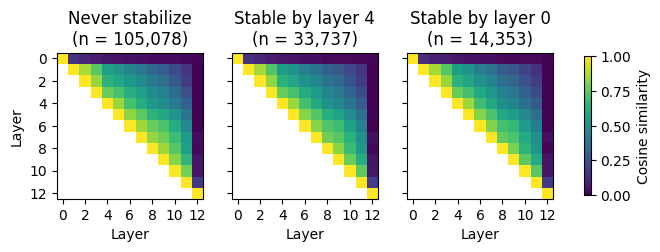

In [43]:

def plot_cossim_matrix(cos_mean_dict, categories, cat_labels, token_count):
    fig, axes = plt.subplots(1, 3, figsize=(8, 3), sharex=True, sharey=True)
    vmin, vmax = 0, 1

    for ax, c in zip(axes, categories):
        mat = cos_mean_dict[c].copy()
        mat[np.triu_indices(N_LAYERS, k=1)] = np.nan
        im = ax.imshow(mat.T, vmin=vmin, vmax=vmax, cmap="viridis", aspect="equal")
        ax.set_title(f"{cat_labels[c]}\n(n = {token_count[c]:,})")
        ax.set_xlabel("Layer")
        if ax is axes[0]:
            ax.set_ylabel("Layer")
        ax.set_xticks(range(0, N_LAYERS, 2))
        ax.set_yticks(range(0, N_LAYERS, 2))

    fig.colorbar(im, ax=axes, shrink=0.6, label="Cosine similarity", pad=0.05)
    return fig

fig2 = plot_cossim_matrix(cos_mean_raw, categories, cat_labels, token_count)
plt.show()

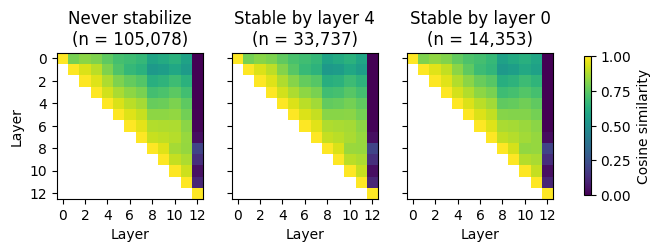

In [44]:
fig3 = plot_cossim_matrix(cos_mean_tl, categories, cat_labels, token_count)
plt.show()